----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1              [-1, 1, 2, 2]              10
         MaxPool2d-2              [-1, 1, 1, 1]               0
              ReLU-3              [-1, 1, 1, 1]               0
           Flatten-4                    [-1, 1]               0
            Linear-5                    [-1, 1]               2
           Sigmoid-6                    [-1, 1]               0
Total params: 12
Trainable params: 12
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------
None


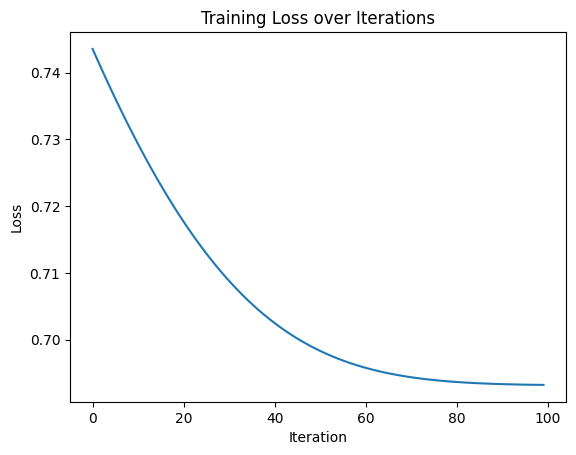

In [8]:
from matplotlib import pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torch.optim import Adam
from torchsummary import summary


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train = torch.tensor([[[[1,2,3,4],[2,3,4,5],[3,4,5,6],[4,5,6,7]]],
                        [[[2,3,4,5],[3,4,5,6],[4,5,6,7],[5,6,7,8]]]]).to(device).float() # Shape: (2, 1, 4, 4)

X_train /= 8
y_train = torch.tensor([[0],[1]]).to(device).float() # Shape: (2, 1)

class MyNet(nn.Module):
    def __init__(self):
        super(MyNet, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1,1,kernel_size=3),
            nn.MaxPool2d(2),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(1,1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.model(x).to(device)
        return x

def train(x, y, model, criterion, optimizer):
    model.train()
    optimizer.zero_grad()
    y_pred = model(x)
    loss = criterion(y_pred, y)
    loss.backward()
    optimizer.step()
    return loss.item()


model = MyNet().to(device)
criterion = nn.BCELoss()
optimizer = Adam(model.parameters(), lr=0.01)
print(summary(model, tuple(X_train.shape[1:])))

losses = []
for epoch in range(100):
    for idx, (x, y) in enumerate(iter(DataLoader(TensorDataset(X_train, y_train), batch_size=2, shuffle=True))):
        loss = train(x, y, model, criterion, optimizer)
        losses.append(loss)
        
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss over Iterations')
plt.show()


